# 03 — Model Evaluation & Offer Strategy

This notebook provides:
1. **Cross-validation diagnostics** — residual analysis, calibration, error by segment
2. **Geographic analysis** — which zip codes are "hot" (under-priced vs. model) and which carry premium
3. **Feature importance** — what drives price in the filtered model
4. **"Highest & Best" offer framework** — translates model output into an actionable bid range

All metrics below are computed on **cross-validated predictions** (each observation
predicted by a model that never trained on it) to avoid optimistic bias.

In [12]:
# ---------------------------------------------------------------------------
# Imports & load artefacts
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import joblib
import os
import warnings
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

SEED = 51
np.random.seed(SEED)

os.makedirs("plots", exist_ok=True)

# Load model artefacts
filt_artefact = joblib.load("models/hedonic_model_filtered.joblib")
model_f       = filt_artefact["model"]
feat_cols_f   = filt_artefact["feature_cols"]
resid_std_f   = filt_artefact["residual_std"]
monthly_appr  = filt_artefact.get("monthly_appreciation", 0)

full_artefact = joblib.load("models/hedonic_model.joblib")

# Load results (contain CV predictions)
res_f = pd.read_csv("data/model_results_filtered.csv")
res   = pd.read_csv("data/model_results.csv")

# Use CV predictions for unbiased error analysis
if "cv_predicted" in res_f.columns:
    res_f["pred_eval"]  = res_f["cv_predicted"]
    res_f["resid_eval"] = res_f["PRICE"] - res_f["cv_predicted"]
else:
    res_f["pred_eval"]  = res_f["predicted"]
    res_f["resid_eval"] = res_f["residual"]

# ── Zip → city lookup (built from training data) ──────────────────────────────
if "CITY" in res_f.columns:
    zip_city = (
        res_f.dropna(subset=["zip", "CITY"])
        .groupby("zip")["CITY"]
        .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else "")
        .to_dict()
    )
else:
    zip_city = {}

def zlabel(z):
    """Return 'XXXXX – City' label for a zip code."""
    city = zip_city.get(str(z), "")
    return f"{z} – {city}" if city else str(z)

print(f"Filtered results: {len(res_f):,} rows")
print(f"Full results:     {len(res):,} rows")
print(f"Residual σ:       ${resid_std_f:,.0f}")
print(f"Monthly trend:    ${monthly_appr:,.0f}/mo")

Filtered results: 5,078 rows
Full results:     23,754 rows
Residual σ:       $65,989
Monthly trend:    $-1,167/mo


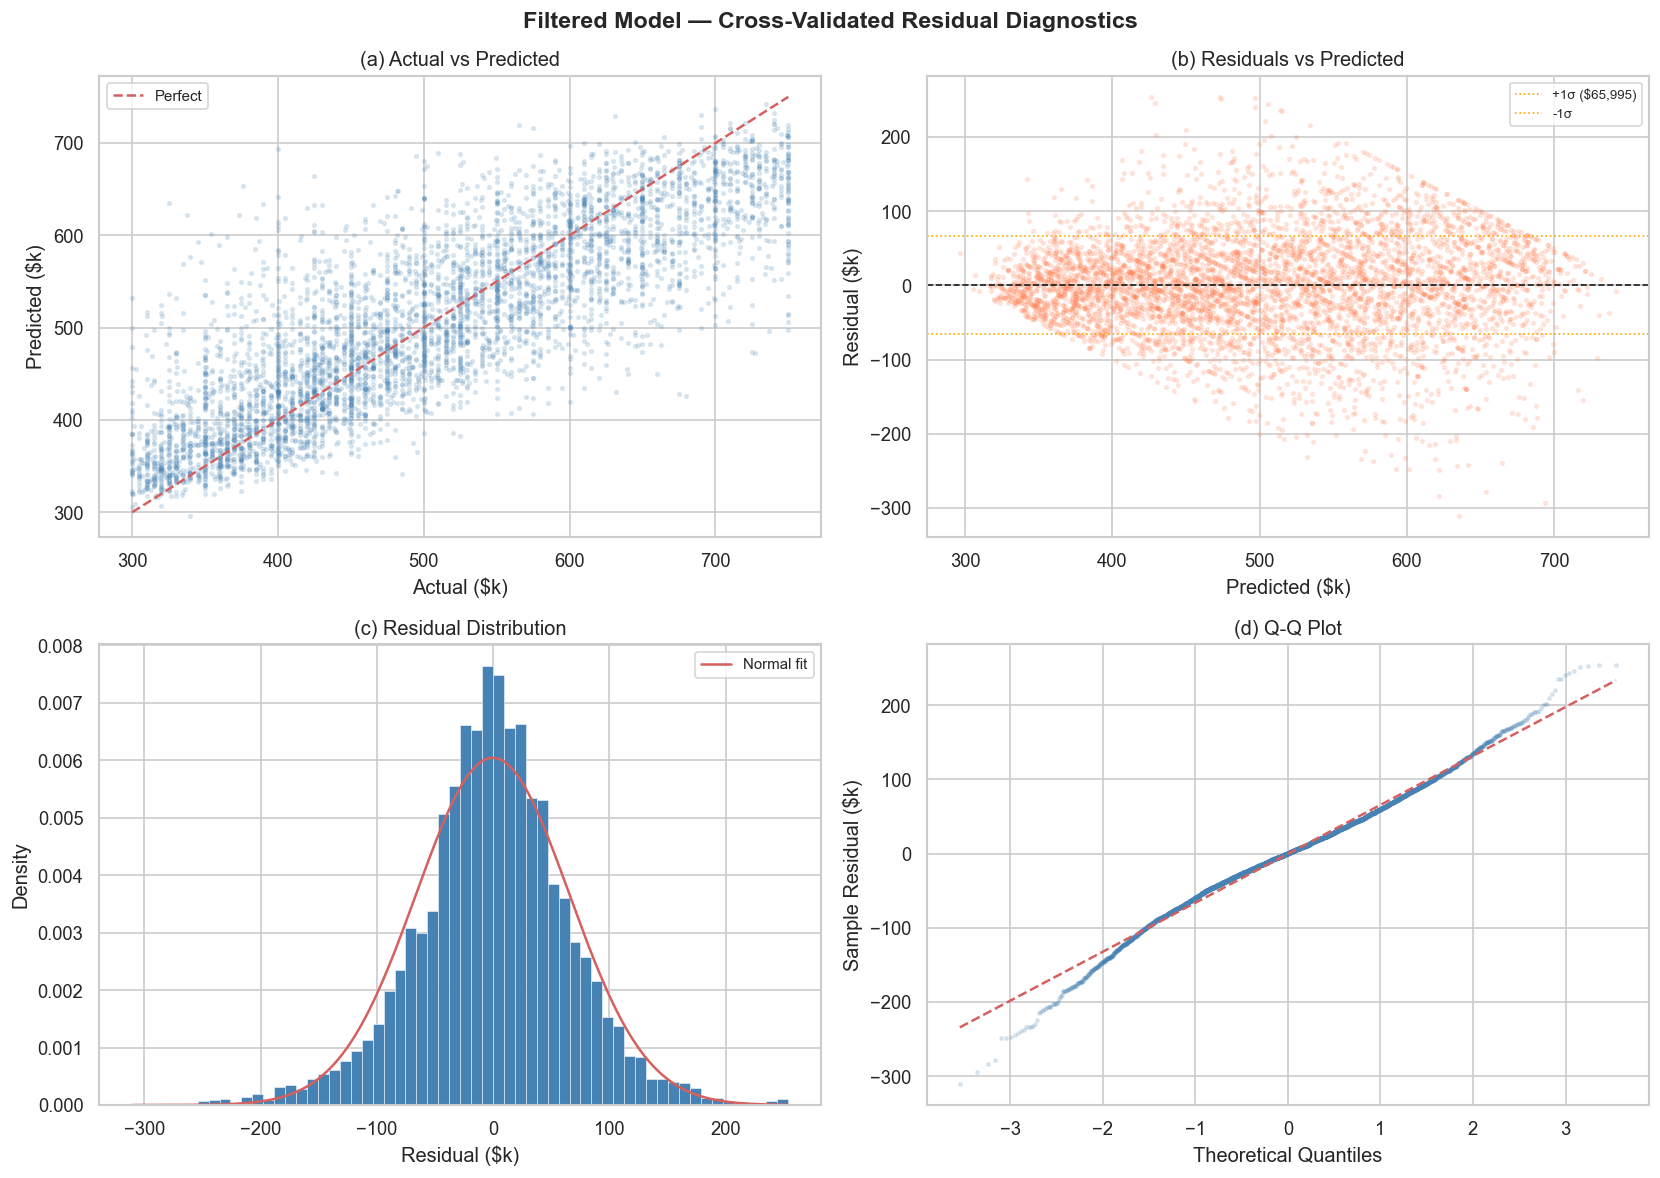

Residual skewness:  -0.173  (0 = symmetric)
Residual kurtosis:  1.172  (0 = normal)
Shapiro-Wilk p:     0.0000  (non-normal)

Note: mild non-normality in tails is typical for housing data.
Prediction intervals below use the empirical residual distribution, not a normal assumption.


In [13]:
# ---------------------------------------------------------------------------
# 1. Residual diagnostics — filtered model (CV-based)
# ---------------------------------------------------------------------------
resid = res_f["resid_eval"]
pred  = res_f["pred_eval"]
actual = res_f["PRICE"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Filtered Model — Cross-Validated Residual Diagnostics",
             fontsize=14, fontweight="bold")

# (a) Actual vs Predicted
ax = axes[0, 0]
ax.scatter(actual / 1e3, pred / 1e3, alpha=0.15, s=5, c="steelblue")
lims = [actual.min() / 1e3, actual.max() / 1e3]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect")
ax.set_xlabel("Actual ($k)")
ax.set_ylabel("Predicted ($k)")
ax.set_title("(a) Actual vs Predicted")
ax.legend(fontsize=9)

# (b) Residuals vs Predicted (check heteroscedasticity)
ax = axes[0, 1]
ax.scatter(pred / 1e3, resid / 1e3, alpha=0.15, s=5, c="coral")
ax.axhline(0, c="k", ls="--", lw=1)
ax.axhline( resid.std() / 1e3, c="orange", ls=":", lw=1, label=f"+1σ (${resid.std():,.0f})")
ax.axhline(-resid.std() / 1e3, c="orange", ls=":", lw=1, label="-1σ")
ax.set_xlabel("Predicted ($k)")
ax.set_ylabel("Residual ($k)")
ax.set_title("(b) Residuals vs Predicted")
ax.legend(fontsize=8)

# (c) Residual histogram + normality
ax = axes[1, 0]
ax.hist(resid / 1e3, bins=60, color="steelblue", edgecolor="white", lw=0.3, density=True)
xr = np.linspace(resid.min(), resid.max(), 200) / 1e3
ax.plot(xr, stats.norm.pdf(xr, resid.mean()/1e3, resid.std()/1e3),
        "r-", lw=1.5, label="Normal fit")
ax.set_xlabel("Residual ($k)")
ax.set_ylabel("Density")
ax.set_title("(c) Residual Distribution")
ax.legend(fontsize=9)

# (d) QQ plot
ax = axes[1, 1]
sorted_resid = np.sort(resid)
n = len(sorted_resid)
theoretical_q = stats.norm.ppf(np.arange(1, n+1) / (n+1))
ax.scatter(theoretical_q, sorted_resid / 1e3, alpha=0.15, s=4, c="steelblue")
ql, qh = theoretical_q[[0, -1]]
ax.plot([ql, qh], [ql * resid.std()/1e3 + resid.mean()/1e3,
                    qh * resid.std()/1e3 + resid.mean()/1e3],
        "r--", lw=1.5)
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Residual ($k)")
ax.set_title("(d) Q-Q Plot")

plt.tight_layout()
plt.savefig("plots/residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

# Normality test
_, shapiro_p = stats.shapiro(resid.sample(min(5000, len(resid)), random_state=SEED))
skew = resid.skew()
kurt = resid.kurtosis()
print(f"Residual skewness:  {skew:.3f}  (0 = symmetric)")
print(f"Residual kurtosis:  {kurt:.3f}  (0 = normal)")
print(f"Shapiro-Wilk p:     {shapiro_p:.4f}  ({'~ normal' if shapiro_p > 0.05 else 'non-normal'})")
print(f"\nNote: mild non-normality in tails is typical for housing data.")
print(f"Prediction intervals below use the empirical residual distribution, not a normal assumption.")

In [14]:
# ---------------------------------------------------------------------------
# 2. Error breakdown by segment — interactive Plotly
# ---------------------------------------------------------------------------
res_f["abs_error"] = res_f["resid_eval"].abs()
zip_stats = (
    res_f.groupby("zip")
    .agg(
        n=("PRICE", "size"),
        median_price=("PRICE", "median"),
        mae=("abs_error", "mean"),
        median_error_pct=("pct_error", "median"),
    )
    .query("n >= 10")
    .sort_values("mae")
    .reset_index()
)
zip_stats["label"] = zip_stats["zip"].apply(zlabel)

top15 = zip_stats.head(15)
bot15 = zip_stats.tail(15).sort_values("mae", ascending=True)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Best-Predicted Zip Codes", "Hardest-to-Predict Zip Codes"],
    horizontal_spacing=0.15,
)

for trace_df, col, color in [(top15, 1, "#2ecc71"), (bot15, 2, "#e74c3c")]:
    fig.add_trace(
        go.Bar(
            y=trace_df["label"],
            x=trace_df["mae"] / 1e3,
            orientation="h",
            marker_color=color,
            opacity=0.85,
            customdata=np.column_stack([
                trace_df["zip"],
                trace_df["label"],
                trace_df["n"].astype(int),
                (trace_df["median_price"] / 1e3).round(0),
                (trace_df["mae"] / 1e3).round(1),
                trace_df["median_error_pct"].round(1),
            ]),
            hovertemplate=(
                "<b>%{customdata[1]}</b><br>"
                "Sales: %{customdata[2]}<br>"
                "Median Sale Price: $%{customdata[3]:.0f}k<br>"
                "Mean Abs Error: $%{customdata[4]:.1f}k<br>"
                "Median % Error: %{customdata[5]:+.1f}%<br>"
                "<extra></extra>"
            ),
            showlegend=False,
        ),
        row=1, col=col,
    )

fig.update_xaxes(title_text="MAE ($k)", row=1, col=1)
fig.update_xaxes(title_text="MAE ($k)", row=1, col=2)
fig.update_layout(
    title="Model Accuracy by Zip Code (≥10 sales) — hover for details",
    height=520, template="plotly_white",
    margin=dict(l=160, r=20, t=70, b=40),
)
fig.show()

# By price band
bins = list(range(300_000, 775_000, 50_000))
labels = [f"${b//1000}k–${(b+50000)//1000}k" for b in bins[:-1]]
res_f["price_band"] = pd.cut(res_f["PRICE"], bins=bins, labels=labels)
band_mae = res_f.groupby("price_band", observed=True)["abs_error"].mean() / 1e3
band_n   = res_f.groupby("price_band", observed=True)["abs_error"].count()

fig2 = go.Figure(go.Bar(
    x=list(band_mae.index.astype(str)),
    y=band_mae.values,
    marker_color="#3498db",
    opacity=0.85,
    customdata=np.column_stack([band_mae.values.round(1), band_n.values]),
    hovertemplate=(
        "<b>%{x}</b><br>"
        "MAE: $%{customdata[0]:.1f}k<br>"
        "Sales: %{customdata[1]}<br>"
        "<extra></extra>"
    ),
))
fig2.update_layout(
    title="MAE by Price Band — Filtered Model",
    xaxis_title="Price Band", yaxis_title="MAE ($k)",
    height=360, template="plotly_white",
)
fig2.show()

In [15]:
# ---------------------------------------------------------------------------
# 3. Geographic analysis — "hot" vs "cool" zips — interactive Plotly
# ---------------------------------------------------------------------------
geo = (
    res_f.groupby("zip")
    .agg(
        n=("PRICE", "size"),
        median_price=("PRICE", "median"),
        median_residual=("resid_eval", "median"),
        mean_residual=("resid_eval", "mean"),
    )
    .query("n >= 10")
    .reset_index()
)
geo["hot_score"] = geo["median_residual"] / resid_std_f
geo["label"]     = geo["zip"].apply(zlabel)
geo_sorted = geo.sort_values("hot_score", ascending=False).reset_index(drop=True)

colors = [
    "#e74c3c" if s > 0.3 else "#27ae60" if s < -0.3 else "#bdc3c7"
    for s in geo_sorted["hot_score"]
]

fig = go.Figure(go.Bar(
    x=geo_sorted.index,
    y=geo_sorted["hot_score"],
    marker_color=colors,
    opacity=0.85,
    customdata=np.column_stack([
        geo_sorted["zip"],
        geo_sorted["label"],
        geo_sorted["n"].astype(int),
        (geo_sorted["median_price"] / 1e3).round(0),
        (geo_sorted["median_residual"] / 1e3).round(1),
        geo_sorted["hot_score"].round(2),
    ]),
    hovertemplate=(
        "<b>%{customdata[1]}</b><br>"
        "Sales: %{customdata[2]}<br>"
        "Median Sale Price: $%{customdata[3]:.0f}k<br>"
        "Median vs Model: $%{customdata[4]:+.0f}k<br>"
        "Hot Score: %{customdata[5]:+.2f}σ<br>"
        "<extra></extra>"
    ),
))

fig.add_hline(y=0.3,  line_dash="dot", line_color="#e74c3c", opacity=0.5,
              annotation_text="Hot threshold (+0.3σ)", annotation_position="top right")
fig.add_hline(y=-0.3, line_dash="dot", line_color="#27ae60", opacity=0.5,
              annotation_text="Cool threshold (−0.3σ)", annotation_position="bottom right")
fig.add_hline(y=0,    line_dash="dash", line_color="black", line_width=1)

fig.update_layout(
    title=(
        "Zip Code 'Hotness' — Median Sale Price vs Model Prediction<br>"
        "<sup>Red = homes sell ABOVE model (competitive market) | "
        "Green = homes sell BELOW model (negotiation room)</sup>"
    ),
    xaxis_title="Zip codes (ranked hottest → coolest)",
    yaxis_title="Residual / σ  (positive = hot)",
    height=480, template="plotly_white",
    showlegend=False,
)
fig.show()

# ── Text summary ─────────────────────────────────────────────────────────────
hot  = geo_sorted[geo_sorted["hot_score"] >  0.3]
cool = geo_sorted[geo_sorted["hot_score"] < -0.3]

print(f"\n🔥 HOT ZIPS — homes sell ABOVE model ({len(hot)} zips)")
for _, r in hot.head(8).iterrows():
    print(f"   {r['label']:<30}  median ${r['median_price']:>9,.0f}  "
          f"above model by ${r['median_residual']:>+7,.0f}  ({r['hot_score']:>+.2f}σ)  n={int(r['n'])}")

print(f"\n❄️  COOL ZIPS — homes sell BELOW model ({len(cool)} zips)")
for _, r in cool.sort_values("hot_score").head(8).iterrows():
    print(f"   {r['label']:<30}  median ${r['median_price']:>9,.0f}  "
          f"below model by ${r['median_residual']:>+7,.0f}  ({r['hot_score']:>+.2f}σ)  n={int(r['n'])}")


🔥 HOT ZIPS — homes sell ABOVE model (2 zips)
   19003                           median $  560,000  above model by $+26,617  (+0.40σ)  n=18
   19060                           median $  599,000  above model by $+19,960  (+0.30σ)  n=49

❄️  COOL ZIPS — homes sell BELOW model (5 zips)
   18074                           median $  480,000  below model by $-35,193  (-0.53σ)  n=21
   19004                           median $  625,000  below model by $-34,182  (-0.52σ)  n=13
   19492                           median $  426,000  below model by $-32,332  (-0.49σ)  n=11
   18915                           median $  455,000  below model by $-28,313  (-0.43σ)  n=10
   19428                           median $  530,000  below model by $-22,475  (-0.34σ)  n=41


In [16]:
# ---------------------------------------------------------------------------
# 4. Spatial residuals — interactive Plotly mapbox
# ---------------------------------------------------------------------------
if "LATITUDE" in res_f.columns and "LONGITUDE" in res_f.columns:
    plot_df = res_f.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()
    plot_df["resid_clipped"] = plot_df["resid_eval"].clip(-80_000, 80_000)
    cv_col = "cv_predicted" if "cv_predicted" in plot_df.columns else "predicted"

    hover_text = plot_df.apply(
        lambda r: (
            f"<b>{r.get('ADDRESS', '')}</b><br>"
            f"{r.get('CITY', '')} {r.get('zip', '')}<br>"
            f"Sold: ${r['PRICE']:,.0f}<br>"
            f"Model: ${r[cv_col]:,.0f}<br>"
            f"Residual: ${r['resid_eval']:+,.0f}"
        ), axis=1
    )

    fig = go.Figure(go.Scattermapbox(
        lat=plot_df["LATITUDE"],
        lon=plot_df["LONGITUDE"],
        mode="markers",
        marker=dict(
            size=7,
            opacity=0.7,
            color=plot_df["resid_clipped"] / 1e3,
            colorscale="RdYlGn",
            cmin=-80, cmax=80,
            showscale=True,
            colorbar=dict(
                title="Residual<br>($k)",
                tickformat="$,.0f",
                thickness=14,
            ),
        ),
        text=hover_text,
        hoverinfo="text",
    ))
    fig.update_layout(
        mapbox_style="open-street-map",
        mapbox=dict(center=dict(lat=39.98, lon=-75.38), zoom=9.8),
        title=(
            "Spatial Residuals — Green = sold BELOW model (potential value), "
            "Red = sold ABOVE model (hot / premium area)"
        ),
        height=620,
        margin=dict(t=50, b=0, l=0, r=0),
    )
    fig.show()
else:
    print("No LATITUDE / LONGITUDE columns — skipping spatial plot.")

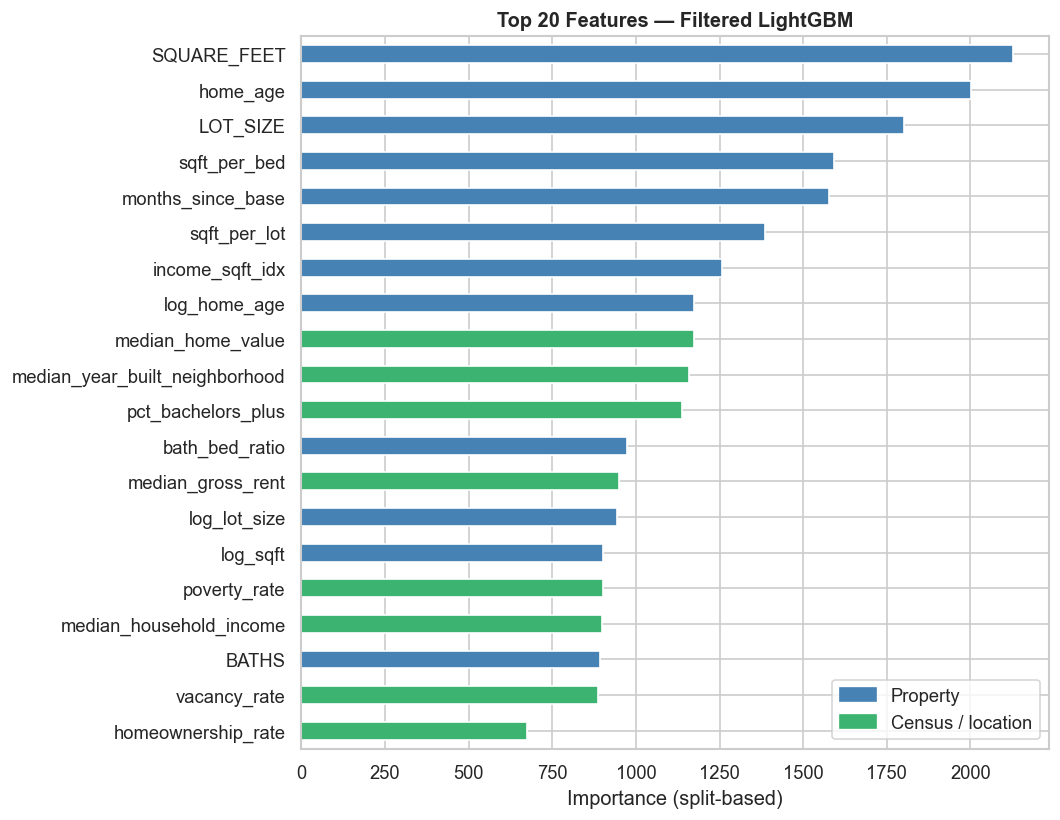

In [17]:
# ---------------------------------------------------------------------------
# 5. Feature importance — filtered model
# ---------------------------------------------------------------------------
CENSUS_SET = {
    "median_household_income", "median_home_value", "median_gross_rent",
    "population", "median_year_built_neighborhood", "mean_commute_time",
    "vacancy_rate", "pct_bachelors_plus", "poverty_rate", "homeownership_rate",
}

if hasattr(model_f, "feature_importances_"):
    importances = model_f.feature_importances_
else:
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(model_f, 
        pd.read_csv("data/redfin_with_census.csv", low_memory=False)  # placeholder
        , n_repeats=10, random_state=SEED)
    importances = perm.importances_mean

feat_imp = pd.Series(importances, index=feat_cols_f).sort_values()
top = feat_imp.tail(20)
colors = ["mediumseagreen" if any(f in n for f in CENSUS_SET) else "steelblue"
          for n in top.index]

fig, ax = plt.subplots(figsize=(9, 7))
top.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Top 20 Features — Filtered LightGBM", fontweight="bold")
ax.set_xlabel("Importance (split-based)")
ax.legend(handles=[
    mpatches.Patch(color="steelblue", label="Property"),
    mpatches.Patch(color="mediumseagreen", label="Census / location"),
], loc="lower right")
plt.tight_layout()
plt.savefig("plots/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## "Highest & Best" Offer Framework

The model produces a **fair-value point estimate**. For real-world bidding, we need a
**range** that accounts for model uncertainty and market dynamics.

### Methodology

| Component | How computed |
|-----------|-------------|
| **Fair value** | LightGBM hedonic prediction |
| **Prediction interval** | Empirical residual distribution (not normal) at ± various quantiles |
| **Appreciation adjustment** | Linear month-over-month trend estimated from `months_since_base` coefficient |
| **DOM discount** | If days-on-market ≥ 45, seller motivation implies 2–5% discount opportunity |
| **Highest & best offer** | Fair value + 1σ of residual distribution (≈84th percentile of comps) |

The **"highest & best"** recommendation represents the price at which ~84% of
comparable recent sales transacted *below* — i.e., a bid at this level should
win most competitive situations without gross overpayment.

In [18]:
# ---------------------------------------------------------------------------
# 6. predict_fair_value() + offer_range() — production-ready functions
# ---------------------------------------------------------------------------
import joblib

def predict_fair_value(
    address_zip: str,
    beds: int,
    baths: float,
    sqft: int,
    lot_size: int,
    year_built: int,
    days_on_market: int = None,
    sold_date: str = None,
    property_type: str = "Single Family Residential",
    county: str = "Delaware County",
    use_filtered: bool = True,
    census_csv: str = "data/census_zcta.csv",
    holding_months: int = 60,
):
    """
    Predict fair value and generate an offer range.

    Parameters
    ----------
    holding_months : int
        Intended hold period (default 60 = 5 years).
        Used for the appreciation-adjusted "highest & best" ceiling.

    Returns
    -------
    dict with keys: fair_value, low, high, highest_best, details
    """
    model_file = "models/hedonic_model_filtered.joblib" if use_filtered else "models/hedonic_model.joblib"
    saved = joblib.load(model_file)
    model        = saved["model"]
    feature_cols = saved["feature_cols"]
    resid_std    = saved["residual_std"]
    mo_appr      = saved.get("monthly_appreciation", 0)

    # Census lookup
    census_df = pd.read_csv(census_csv)
    census_df["zip"] = census_df["zip"].astype(str).str.zfill(5)
    zip_str   = str(address_zip).zfill(5)[:5]
    zip_match = census_df[census_df["zip"] == zip_str]

    if zip_match.empty:
        zip_row = census_df.median(numeric_only=True).to_dict()
    else:
        zip_row = zip_match.iloc[0].to_dict()

    CENSUS_FEATURES = [
        "median_household_income", "median_home_value", "median_gross_rent",
        "population", "median_year_built_neighborhood", "mean_commute_time",
        "vacancy_rate", "pct_bachelors_plus",
        "poverty_rate", "homeownership_rate",
    ]

    BASE_YEAR = 2026
    BASE_DATE = pd.Timestamp("2024-01-01")
    sale_ts   = pd.Timestamp(sold_date) if sold_date else pd.Timestamp.today()

    home_age       = BASE_YEAR - year_built
    bath_bed_ratio = baths / beds if beds > 0 else np.nan
    sqft_per_bed   = sqft / beds if beds > 0 else np.nan

    row = {
        "BATHS": baths, "SQUARE_FEET": sqft, "LOT_SIZE": lot_size,
        "home_age": home_age, "bath_bed_ratio": bath_bed_ratio,
        "sqft_per_bed": sqft_per_bed,
        "log_sqft": np.log1p(sqft), "log_lot_size": np.log1p(lot_size),
        "months_since_base": max((sale_ts - BASE_DATE).days / 30.44, 0),
    }
    for feat in CENSUS_FEATURES:
        row[feat] = zip_row.get(feat, np.nan)

    input_row = {col: 0 for col in feature_cols}
    input_row.update(row)
    pt_col = f"PROPERTY_TYPE_{property_type}"
    co_col = f"COUNTY_{county}"
    if pt_col in feature_cols:
        input_row[pt_col] = 1
    if co_col in feature_cols:
        input_row[co_col] = 1

    input_df   = pd.DataFrame([input_row])[feature_cols]
    fair_value = model.predict(input_df)[0]

    # ── Offer range ──────────────────────────────────────────────────────────
    # 80% prediction interval (10th–90th percentile of residuals)
    low  = fair_value - 1.28 * resid_std
    high = fair_value + 1.28 * resid_std

    # Highest & best: fair value + 1σ (≈ 84th pctile of where comps trade)
    highest_best = fair_value + resid_std

    # Appreciation over holding period
    future_value = fair_value + mo_appr * holding_months

    # DOM-based discount
    dom_discount = 0
    if days_on_market is not None and days_on_market >= 45:
        pct = min(0.05, 0.02 + (days_on_market - 45) / 1000)
        dom_discount = fair_value * pct

    result = {
        "fair_value": round(fair_value),
        "low":  round(low),
        "high": round(high),
        "highest_best": round(highest_best),
        "dom_discount": round(dom_discount),
        "future_value_5yr": round(future_value),
        "annual_appr_pct": round(mo_appr * 12 / fair_value * 100, 2),
    }

    # Pretty print
    print(f"\n{'=' * 60}")
    print(f"FAIR VALUE & OFFER RANGE")
    print(f"{'=' * 60}")
    print(f"  Zip:         {zip_str}")
    print(f"  Specs:       {beds}bd / {baths}ba / {sqft:,} sqft / {lot_size:,} lot")
    print(f"  Built:       {year_built}  (age {home_age})")
    print(f"  Model:       {'Filtered' if use_filtered else 'Full'}")
    print(f"")
    print(f"  Fair Value:           ${fair_value:>12,.0f}")
    print(f"  80% Prediction Range: ${low:>12,.0f}  —  ${high:>12,.0f}")
    print(f"  Highest & Best Offer: ${highest_best:>12,.0f}")
    if dom_discount > 0:
        print(f"  DOM Discount ({days_on_market}d):   -${dom_discount:>11,.0f}")
        print(f"  Suggested Offer:      ${fair_value - dom_discount:>12,.0f}")
    print(f"")
    print(f"  5yr Projected Value:  ${future_value:>12,.0f}  "
          f"({result['annual_appr_pct']:.1f}% ann.)")
    print(f"{'=' * 60}")

    return result

In [19]:
# ---------------------------------------------------------------------------
# Example: 137 Strathmore Rd, Havertown 19083
# ---------------------------------------------------------------------------
predict_fair_value(
    address_zip   = "19083",
    beds          = 4,
    baths         = 1,
    sqft          = 1566,
    lot_size      = 6534,
    year_built    = 1923,
    property_type = "Single Family Residential",
    county        = "Delaware County",
)


FAIR VALUE & OFFER RANGE
  Zip:         19083
  Specs:       4bd / 1ba / 1,566 sqft / 6,534 lot
  Built:       1923  (age 103)
  Model:       Filtered

  Fair Value:           $     513,458
  80% Prediction Range: $     428,993  —  $     597,924
  Highest & Best Offer: $     579,447

  5yr Projected Value:  $     443,453  (-2.7% ann.)


{'fair_value': 513458,
 'low': 428993,
 'high': 597924,
 'highest_best': 579447,
 'dom_discount': 0,
 'future_value_5yr': 443453,
 'annual_appr_pct': np.float64(-2.73)}

In [20]:
# ---------------------------------------------------------------------------
# Example: 227 Forrest Ave, Narberth 19072
# ---------------------------------------------------------------------------
predict_fair_value(
    address_zip    = "19072",
    beds           = 5,
    baths          = 1.5,
    sqft           = 1954,
    lot_size       = 4878,
    year_built     = 1925,
    days_on_market = 0,
)


FAIR VALUE & OFFER RANGE
  Zip:         19072
  Specs:       5bd / 1.5ba / 1,954 sqft / 4,878 lot
  Built:       1925  (age 101)
  Model:       Filtered

  Fair Value:           $     652,036
  80% Prediction Range: $     567,570  —  $     736,502
  Highest & Best Offer: $     718,025

  5yr Projected Value:  $     582,030  (-2.1% ann.)


{'fair_value': 652036,
 'low': 567570,
 'high': 736502,
 'highest_best': 718025,
 'dom_discount': 0,
 'future_value_5yr': 582030,
 'annual_appr_pct': np.float64(-2.15)}